# Known-PSF deconvolution with official USRNet (A100)

This notebook keeps the assignment degradation unchanged and explicitly supplies the known dipole PSF and normalized noise level to official USRNet.

Default experiment: fixed `B0_dir=(0.0, 1.0)`, `test_deconv_only`, and zero added noise. It compares Wiener, pretrained USRNet, and fine-tuned USRNet on identical files.

## 0. Colab setup

Use an A100 runtime. Data are copied from `dataset.zip` on Drive to `/content`; checkpoints and metrics stay on Drive.

In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import gc
import json
import math
import os
import random
import shutil
import subprocess
import sys
import time
import urllib.request
import zipfile
from contextlib import nullcontext
from dataclasses import asdict, dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

if not torch.cuda.is_available():
    raise RuntimeError("Select a GPU runtime (A100 recommended).")
DEVICE = torch.device("cuda")
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.set_float32_matmul_precision("high")
print(torch.cuda.get_device_name(0), torch.__version__)

NVIDIA A100-SXM4-80GB 2.11.0+cu128


In [3]:
DRIVE_ROOT = Path("/content/drive/MyDrive/Data scientist/팀프로젝트/5주차")
DRIVE_ARCHIVE = DRIVE_ROOT / "dataset.zip"
CONTENT_ARCHIVE = Path("/content/dataset.zip")
DATA_ROOT = Path("/content/dataset")
RUN_DIR = DRIVE_ROOT / "logs_deconvolution_usrnet"
RUN_DIR.mkdir(parents=True, exist_ok=True)

REQUIRED_SPLITS = ("train", "val", "test_label", "test_deconv_only")

def stage_dataset():
    if not DRIVE_ARCHIVE.is_file():
        raise FileNotFoundError(f"Missing archive: {DRIVE_ARCHIVE}")
    if not all((DATA_ROOT / split).is_dir() for split in REQUIRED_SPLITS):
        shutil.copy2(DRIVE_ARCHIVE, CONTENT_ARCHIVE)
        with zipfile.ZipFile(CONTENT_ARCHIVE) as archive:
            archive.extractall("/content")
    missing = [split for split in REQUIRED_SPLITS if not (DATA_ROOT / split).is_dir()]
    if missing:
        raise FileNotFoundError(f"dataset.zip missing: {missing}")
    for split in REQUIRED_SPLITS:
        print(f"{split:18s}: {len(list((DATA_ROOT / split).glob('*.npy'))):5d}")

stage_dataset()

train             :  7268
val               :   100
test_label        :   100
test_deconv_only  :   100


In [4]:
USRNET_REPO_URL = "https://github.com/cszn/USRNet.git"
USRNET_REPO = Path("/content/USRNet")
USRNET_WEIGHT_URL = "https://github.com/cszn/KAIR/releases/download/v1.0/usrnet.pth"
USRNET_WEIGHT = RUN_DIR / "usrnet.pth"

if not USRNET_REPO.is_dir():
    subprocess.run(["git", "clone", "--depth", "1", USRNET_REPO_URL, str(USRNET_REPO)], check=True)
if not (USRNET_REPO / "models" / "network_usrnet_v1.py").is_file():
    raise FileNotFoundError("Official network_usrnet_v1.py is missing")
if not USRNET_WEIGHT.is_file():
    urllib.request.urlretrieve(USRNET_WEIGHT_URL, USRNET_WEIGHT)
if USRNET_WEIGHT.stat().st_size < 1_000_000:
    raise RuntimeError("Downloaded usrnet.pth is unexpectedly small")
if str(USRNET_REPO) not in sys.path:
    sys.path.insert(0, str(USRNET_REPO))
print("repo:", USRNET_REPO)
print("weight:", USRNET_WEIGHT, f"({USRNET_WEIGHT.stat().st_size / 2**20:.1f} MiB)")

repo: /content/USRNet
weight: /content/drive/MyDrive/Data scientist/팀프로젝트/5주차/logs_deconvolution_usrnet/usrnet.pth (64.9 MiB)


In [16]:
B0_DIR = (0.0, 1.0)
SF = 1
NOISE_STD = 0.0
MAX_EPOCHS = 200
PSF_ROUNDTRIP_TOL = 1e-5

@dataclass
class Config:
    B0_DIR: tuple[float, float] = (0.0, 1.0)
    SF: int = 1
    NOISE_STD: float = 0.0
    MAX_EPOCHS: int = 200
    TRAIN_PATCH: int = 96
    TRAIN_BATCH: int = 8
    EVAL_BATCH: int = 1
    NUM_WORKERS: int = 2
    ACCUM_STEPS: int = 2
    LR: float = 1e-5
    WEIGHT_DECAY: float = 0.0
    GRAD_CLIP: float = 1.0
    EARLY_STOPPING_PATIENCE: int = 30
    MIN_DELTA_PSNR: float = 1e-3
    PSF_ROUNDTRIP_TOL: float = 1e-5
    WIENER_K_GRID: tuple[float, ...] = (1e-2, 3e-3, 1e-3, 3e-4, 1e-4, 3e-5, 1e-5)
    SAVE_FIGURES: int = 6
    ENABLE_MULTI_TEST: bool = False

CFG = Config()
B0_DIR = CFG.B0_DIR
SF = CFG.SF
NOISE_STD = CFG.NOISE_STD
MAX_EPOCHS = CFG.MAX_EPOCHS
PSF_ROUNDTRIP_TOL = CFG.PSF_ROUNDTRIP_TOL
print(asdict(CFG))

{'B0_DIR': (0.0, 1.0), 'SF': 1, 'NOISE_STD': 0.0, 'MAX_EPOCHS': 200, 'TRAIN_PATCH': 96, 'TRAIN_BATCH': 8, 'EVAL_BATCH': 1, 'NUM_WORKERS': 2, 'ACCUM_STEPS': 2, 'LR': 1e-05, 'WEIGHT_DECAY': 0.0, 'GRAD_CLIP': 1.0, 'EARLY_STOPPING_PATIENCE': 30, 'MIN_DELTA_PSNR': 0.001, 'PSF_ROUNDTRIP_TOL': 1e-05, 'WIENER_K_GRID': (0.01, 0.003, 0.001, 0.0003, 0.0001, 3e-05, 1e-05), 'SAVE_FIGURES': 6, 'ENABLE_MULTI_TEST': False}


## 1. Exact dipole OTF → USRNet spatial PSF

USRNet internally converts a spatial PSF with `p2o`. The assignment function already returns an OTF, so we invert and center it. The signed dipole PSF is deliberately **not** divided by its sum; doing that would change the measurement operator.

In [17]:
def dipole_otf(matrix_size, voxel_size=(1.0, 1.0), b0_dir=B0_DIR, device="cpu"):
    rows, cols = matrix_size
    y = torch.arange(-cols / 2, cols / 2, dtype=torch.float64, device=device)
    x = torch.arange(-rows / 2, rows / 2, dtype=torch.float64, device=device)
    yy, xx = torch.meshgrid(y, x, indexing="xy")
    xx = xx / (rows * voxel_size[0])
    yy = yy / (cols * voxel_size[1])
    otf = 1.0 / 3.0 - (xx * b0_dir[0] + yy * b0_dir[1]).square() / (xx.square() + yy.square() + 1e-8)
    return torch.fft.fftshift(otf).float()


def degrade_clean(clean, otf, noise_std=NOISE_STD):
    degraded = torch.fft.ifft2(torch.fft.fft2(clean) * otf).real
    if noise_std > 0:
        degraded = degraded + torch.randn_like(degraded) * noise_std
    return degraded


def otf_to_usrnet_psf(otf):
    return torch.fft.fftshift(torch.fft.ifft2(otf).real)


def p2o_modern(psf, shape):
    out = torch.zeros(psf.shape[:-2] + tuple(shape), dtype=psf.dtype, device=psf.device)
    out[..., :psf.shape[-2], :psf.shape[-1]].copy_(psf)
    out = torch.roll(out, -(psf.shape[-2] // 2), dims=-2)
    out = torch.roll(out, -(psf.shape[-1] // 2), dims=-1)
    return torch.fft.fft2(out)


def validate_psf_adapter(shape=(256, 256)):
    otf = dipole_otf(shape)
    psf = otf_to_usrnet_psf(otf)
    rebuilt = p2o_modern(psf[None, None], shape)[0, 0]
    error = (rebuilt - otf).abs().max().item()
    assert error < PSF_ROUNDTRIP_TOL, (error, PSF_ROUNDTRIP_TOL)
    assert psf.min() < 0 and torch.isfinite(psf).all()
    assert not torch.isclose(psf.sum(), torch.tensor(1.0), atol=1e-6)
    print(f"shape={shape} psf range=[{psf.min():.3e}, {psf.max():.3e}] sum={psf.sum():.6f}")
    print(f"p2o round-trip max error={error:.3e}")
    return otf, psf

_ = validate_psf_adapter()

shape=(256, 256) psf range=[-1.667e-01, 1.526e-01] sum=0.333333
p2o round-trip max error=2.982e-07


## 2. Dataset

Train/validation degradation is generated on the fly with fixed B0. The test set loads the supplied `test_deconv_only` measurements and pairs them to clean labels by filename.

In [18]:
class KnownPSFDataset(Dataset):
    def __init__(self, clean_dir, measure_dir=None, training=False, patch_size=None):
        self.clean_dir = Path(clean_dir)
        self.measure_dir = Path(measure_dir) if measure_dir is not None else None
        self.training = training
        self.patch_size = patch_size
        self.files = sorted(self.clean_dir.glob("*.npy"))
        if not self.files:
            raise FileNotFoundError(f"No npy files: {self.clean_dir}")
        if self.measure_dir is not None:
            missing = [p.name for p in self.files if not (self.measure_dir / p.name).is_file()]
            if missing:
                raise FileNotFoundError(f"Missing paired measurements, first={missing[0]}")

    @staticmethod
    def load_npy(path):
        array = np.load(path).astype(np.float32)
        array = np.squeeze(array)
        if array.ndim != 2:
            raise ValueError(f"Expected 2D image: {path}, got {array.shape}")
        tensor = torch.from_numpy(array).unsqueeze(0)
        if not torch.isfinite(tensor).all():
            raise ValueError(f"Non-finite values: {path}")
        return tensor

    def __len__(self):
        return len(self.files)

    def __getitem__(self, index):
        clean_path = self.files[index]
        clean = self.load_npy(clean_path)
        measure = self.load_npy(self.measure_dir / clean_path.name) if self.measure_dir is not None else None

        if self.training and random.random() < 0.5:
            clean = torch.flip(clean, (-1,))
            measure = torch.flip(measure, (-1,)) if measure is not None else None
        if self.training and random.random() < 0.5:
            clean = torch.flip(clean, (-2,))
            measure = torch.flip(measure, (-2,)) if measure is not None else None

        if self.training and self.patch_size is not None:
            _, h, w = clean.shape
            size = self.patch_size
            if h < size or w < size:
                raise ValueError(f"Image {clean_path.name} smaller than patch {size}")
            top = random.randint(0, h - size)
            left = random.randint(0, w - size)
            clean = clean[:, top:top + size, left:left + size]
            if measure is not None:
                measure = measure[:, top:top + size, left:left + size]

        otf = dipole_otf(tuple(clean.shape[-2:]))
        psf = otf_to_usrnet_psf(otf).unsqueeze(0)
        if measure is None:
            measure = degrade_clean(clean, otf, NOISE_STD)
        sigma = torch.tensor([[[NOISE_STD]]], dtype=torch.float32)
        return {"clean": clean, "degraded": measure, "kernel": psf, "sigma": sigma, "name": clean_path.name}


def make_loader(dataset, batch_size, shuffle):
    return DataLoader(
        dataset, batch_size=batch_size, shuffle=shuffle,
        num_workers=CFG.NUM_WORKERS, pin_memory=True,
        persistent_workers=CFG.NUM_WORKERS > 0,
        prefetch_factor=2 if CFG.NUM_WORKERS > 0 else None,
    )

train_set = KnownPSFDataset(DATA_ROOT / "train", training=True, patch_size=CFG.TRAIN_PATCH)
val_set = KnownPSFDataset(DATA_ROOT / "val")
test_set = KnownPSFDataset(DATA_ROOT / "test_label", DATA_ROOT / "test_deconv_only")
train_loader = make_loader(train_set, CFG.TRAIN_BATCH, True)
val_loader = make_loader(val_set, CFG.EVAL_BATCH, False)
test_loader = make_loader(test_set, CFG.EVAL_BATCH, False)
print(len(train_set), len(val_set), len(test_set))

7268 100 100


In [19]:
batch = next(iter(train_loader))
for key in ("clean", "degraded", "kernel", "sigma"):
    print(key, tuple(batch[key].shape), batch[key].dtype)
assert batch["clean"].shape == batch["degraded"].shape
assert batch["kernel"].shape[1] == 1
assert batch["sigma"].shape[1:] == (1, 1, 1)
assert torch.all(batch["sigma"] == NOISE_STD)

clean (8, 1, 96, 96) torch.float32
degraded (8, 1, 96, 96) torch.float32
kernel (8, 1, 96, 96) torch.float32
sigma (8, 1, 1, 1) torch.float32


## 3. Official pretrained USRNet

The official checkpoint is RGB. To preserve it exactly, grayscale measurement and GT are repeated to three channels. The restored RGB channels are averaged only for grayscale evaluation.

In [20]:
from models.network_usrnet_v1 import USRNet


def build_official_usrnet():
    model = USRNet(
        n_iter=8, h_nc=64, in_nc=4, out_nc=3,
        nc=[64, 128, 256, 512], nb=2, act_mode="R",
        downsample_mode="strideconv", upsample_mode="convtranspose",
    )
    state = torch.load(USRNET_WEIGHT, map_location="cpu", weights_only=True)
    if isinstance(state, dict) and "params" in state:
        state = state["params"]
    incompatible = model.load_state_dict(state, strict=True)
    assert not incompatible.missing_keys and not incompatible.unexpected_keys
    return model.to(DEVICE)

model = build_official_usrnet()
print(f"parameters={sum(p.numel() for p in model.parameters()):,}")

parameters=17,016,016


In [21]:
def usrnet_restore(model, degraded, kernel, sigma):
    degraded = degraded.to(DEVICE, non_blocking=True)
    kernel = kernel.to(DEVICE, non_blocking=True)
    sigma = sigma.to(DEVICE, non_blocking=True)
    degraded_rgb = degraded.repeat(1, 3, 1, 1)
    output_rgb = model(degraded_rgb, kernel, SF, sigma)
    return output_rgb.mean(dim=1, keepdim=True)


def batch_psnr(prediction, target):
    prediction = prediction.float().clamp(0.0, 1.0)
    target = target.float()
    mse = (prediction - target).square().flatten(1).mean(1).clamp_min(1e-12)
    return 10.0 * torch.log10(1.0 / mse)


def evaluate_usrnet(model, loader, description):
    model.eval()
    rows = []
    with torch.inference_mode():
        for batch in tqdm(loader, desc=description):
            clean = batch["clean"].to(DEVICE, non_blocking=True)
            restored = usrnet_restore(model, batch["degraded"], batch["kernel"], batch["sigma"])
            scores = batch_psnr(restored, clean)
            for name, score in zip(batch["name"], scores.cpu().tolist()):
                rows.append({"file": name, "psnr": score})
    result = pd.DataFrame(rows)
    print(description, f"PSNR={result.psnr.mean():.3f} dB")
    return result

### 3.1 Pretrained inference smoke test — run before any optimizer exists

In [22]:
model.eval()
smoke = next(iter(val_loader))
with torch.inference_mode():
    smoke_output = usrnet_restore(model, smoke["degraded"], smoke["kernel"], smoke["sigma"])
assert smoke_output.shape == smoke["clean"].shape
assert torch.isfinite(smoke_output).all()
print("pretrained smoke:", tuple(smoke_output.shape), batch_psnr(smoke_output, smoke["clean"].to(DEVICE)).mean().item())

pretrained smoke: (1, 1, 256, 256) 46.0184440612793


In [23]:
pretrained_val_metrics = evaluate_usrnet(model, val_loader, "pretrained validation")
pretrained_state_cpu = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
pretrained_val_metrics.to_csv(RUN_DIR / "pretrained_val_metrics.csv", index=False)

pretrained validation:   0%|          | 0/100 [00:00<?, ?it/s]

pretrained validation PSNR=46.369 dB


## 4. Wiener validation selection

`K` is selected only on validation and then frozen. This avoids tuning the baseline on the test set.

In [24]:
def wiener_restore(degraded, otf, k_value):
    spectrum = torch.fft.fft2(degraded)
    restored = torch.fft.ifft2(torch.conj(otf) * spectrum / (otf.abs().square() + k_value)).real
    return restored


def evaluate_wiener(loader, k_value, description):
    rows = []
    with torch.inference_mode():
        for batch in tqdm(loader, desc=description):
            clean = batch["clean"].to(DEVICE, non_blocking=True)
            degraded = batch["degraded"].to(DEVICE, non_blocking=True)
            otf = dipole_otf(tuple(clean.shape[-2:]), device=DEVICE)
            restored = wiener_restore(degraded, otf, k_value)
            scores = batch_psnr(restored, clean)
            for name, score in zip(batch["name"], scores.cpu().tolist()):
                rows.append({"file": name, "psnr": score})
    result = pd.DataFrame(rows)
    print(description, f"PSNR={result.psnr.mean():.3f} dB")
    return result

wiener_validation = []
for candidate_k in CFG.WIENER_K_GRID:
    metrics = evaluate_wiener(val_loader, candidate_k, f"Wiener val K={candidate_k:g}")
    wiener_validation.append({"K": candidate_k, "psnr": metrics.psnr.mean()})
wiener_validation = pd.DataFrame(wiener_validation).sort_values("psnr", ascending=False)
BEST_WIENER_K = float(wiener_validation.iloc[0].K)
wiener_validation.to_csv(RUN_DIR / "wiener_validation_sweep.csv", index=False)
print(wiener_validation)
print("frozen BEST_WIENER_K=", BEST_WIENER_K)

Wiener val K=0.01:   0%|          | 0/100 [00:00<?, ?it/s]

Wiener val K=0.01 PSNR=26.287 dB


Wiener val K=0.003:   0%|          | 0/100 [00:00<?, ?it/s]

Wiener val K=0.003 PSNR=32.510 dB


Wiener val K=0.001:   0%|          | 0/100 [00:00<?, ?it/s]

...

Wiener val K=0.0001 PSNR=44.102 dB


Wiener val K=3e-05:   0%|          | 0/100 [00:00<?, ?it/s]

Wiener val K=3e-05 PSNR=47.383 dB


Wiener val K=1e-05:   0%|          | 0/100 [00:00<?, ?it/s]

Wiener val K=1e-05 PSNR=50.751 dB
         K       psnr
6  0.00001  50.751499
5  0.00003  47.383048
4  0.00010  44.101545
3  0.00030  40.911756
2  0.00100  36.852972
1  0.00300  32.510078
0  0.01000  26.286754
frozen BEST_WIENER_K= 1e-05


## 5. Fine-tuning

All official USRNet parameters start from `usrnet.pth`. L1 is computed against three repeated clean channels, matching the unchanged pretrained RGB architecture. Best selection uses validation PSNR.

In [25]:
BEST_CHECKPOINT = RUN_DIR / "best_usrnet.pth"
LATEST_CHECKPOINT = RUN_DIR / "latest_usrnet.pth"
TRAIN_HISTORY = RUN_DIR / "train_history.csv"
RESUME = True


def save_checkpoint(path, model, optimizer, scheduler, epoch, best_psnr, stale_epochs):
    payload = {
        "epoch": epoch,
        "model": {k: v.detach().cpu() for k, v in model.state_dict().items()},
        "optimizer": optimizer.state_dict(),
        "scheduler": scheduler.state_dict(),
        "best_psnr": best_psnr,
        "stale_epochs": stale_epochs,
        "config": asdict(CFG),
    }
    torch.save(payload, path)


def fine_tune_usrnet(model, train_loader, val_loader):
    optimizer = torch.optim.Adam(model.parameters(), lr=CFG.LR, weight_decay=CFG.WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS, eta_min=CFG.LR * 0.05)
    loss_fn = nn.L1Loss()
    start_epoch, best_psnr, stale_epochs = 1, -math.inf, 0
    history = []

    if RESUME and LATEST_CHECKPOINT.is_file():
        checkpoint = torch.load(LATEST_CHECKPOINT, map_location="cpu", weights_only=False)
        model.load_state_dict(checkpoint["model"], strict=True)
        optimizer.load_state_dict(checkpoint["optimizer"])
        scheduler.load_state_dict(checkpoint["scheduler"])
        start_epoch = int(checkpoint["epoch"]) + 1
        best_psnr = float(checkpoint["best_psnr"])
        stale_epochs = int(checkpoint["stale_epochs"])
        print(f"resumed at epoch {start_epoch}, best={best_psnr:.3f}")

    for epoch in range(start_epoch, MAX_EPOCHS + 1):
        model.train()
        optimizer.zero_grad(set_to_none=True)
        running_loss = 0.0
        seen = 0
        progress = tqdm(train_loader, desc=f"train {epoch}/{MAX_EPOCHS}")
        for step, batch in enumerate(progress, start=1):
            clean = batch["clean"].to(DEVICE, non_blocking=True)
            degraded = batch["degraded"].to(DEVICE, non_blocking=True)
            kernel = batch["kernel"].to(DEVICE, non_blocking=True)
            sigma = batch["sigma"].to(DEVICE, non_blocking=True)
            with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
                output_rgb = model(degraded.repeat(1, 3, 1, 1), kernel, SF, sigma)
                loss = loss_fn(output_rgb, clean.repeat(1, 3, 1, 1))
                scaled_loss = loss / CFG.ACCUM_STEPS
            scaled_loss.backward()
            running_loss += loss.detach().item() * clean.shape[0]
            seen += clean.shape[0]

            if step % CFG.ACCUM_STEPS == 0 or step == len(train_loader):
                torch.nn.utils.clip_grad_norm_(model.parameters(), CFG.GRAD_CLIP)
                optimizer.step()
                optimizer.zero_grad(set_to_none=True)
            progress.set_postfix(loss=f"{running_loss / seen:.5f}", lr=f"{optimizer.param_groups[0]['lr']:.2e}")

        validation = evaluate_usrnet(model, val_loader, f"validation epoch {epoch}")
        val_psnr = float(validation.psnr.mean())
        scheduler.step()
        improved = val_psnr > best_psnr + CFG.MIN_DELTA_PSNR
        if improved:
            best_psnr, stale_epochs = val_psnr, 0
            save_checkpoint(BEST_CHECKPOINT, model, optimizer, scheduler, epoch, best_psnr, stale_epochs)
        else:
            stale_epochs += 1
        save_checkpoint(LATEST_CHECKPOINT, model, optimizer, scheduler, epoch, best_psnr, stale_epochs)
        history.append({
            "epoch": epoch, "train_l1": running_loss / seen, "val_psnr": val_psnr,
            "best_psnr": best_psnr, "lr": optimizer.param_groups[0]["lr"], "improved": improved,
        })
        pd.DataFrame(history).to_csv(TRAIN_HISTORY, index=False)
        print(history[-1])
        if stale_epochs >= CFG.EARLY_STOPPING_PATIENCE:
            print(f"early stopping after {stale_epochs} epochs without improvement")
            break
    return pd.DataFrame(history)

training_history = fine_tune_usrnet(model, train_loader, val_loader)
print("best checkpoint:", BEST_CHECKPOINT)

train 1/200:   0%|          | 0/909 [00:00<?, ?it/s]

validation epoch 1:   0%|          | 0/100 [00:00<?, ?it/s]

validation epoch 1 PSNR=59.490 dB
{'epoch': 1, 'train_l1': 0.0012764319622823553, 'val_psnr': 59.48984233856201, 'best_psnr': 59.48984233856201, 'lr': 9.999414004287889e-06, 'improved': True}


train 2/200:   0%|          | 0/909 [00:00<?, ?it/s]

validation epoch 2:   0%|          | 0/100 [00:00<?, ?it/s]

...

validation epoch 69:   0%|          | 0/100 [00:00<?, ?it/s]

validation epoch 69 PSNR=63.597 dB
{'epoch': 69, 'train_l1': 0.000696038737441795, 'val_psnr': 63.597439994812014, 'best_psnr': 64.62337989807129, 'lr': 7.472666617737727e-06, 'improved': False}


train 70/200:   0%|          | 0/909 [00:00<?, ?it/s]

validation epoch 70:   0%|          | 0/100 [00:00<?, ?it/s]

validation epoch 70 PSNR=63.761 dB
{'epoch': 70, 'train_l1': 0.000693605484034206, 'val_psnr': 63.76069164276123, 'best_psnr': 64.62337989807129, 'lr': 7.40645487376285e-06, 'improved': False}
early stopping after 30 epochs without improvement
best checkpoint: /content/drive/MyDrive/Data scientist/팀프로젝트/5주차/logs_deconvolution_usrnet/best_usrnet.pth


## 6. Matched test comparison

Every method uses the same `test_deconv_only` measurement and `test_label` GT. The pretrained checkpoint is evaluated first, then the validation-selected fine-tuned checkpoint.

In [26]:
def evaluate_measurement(loader):
    rows = []
    for batch in loader:
        clean = batch["clean"].to(DEVICE, non_blocking=True)
        degraded = batch["degraded"].to(DEVICE, non_blocking=True)
        scores = batch_psnr(degraded, clean)
        rows.extend({"file": name, "psnr": score} for name, score in zip(batch["name"], scores.cpu().tolist()))
    return pd.DataFrame(rows)

measurement_test = evaluate_measurement(test_loader).rename(columns={"psnr": "measurement"})
wiener_test = evaluate_wiener(test_loader, BEST_WIENER_K, "Wiener test").rename(columns={"psnr": "Wiener"})

model.load_state_dict(pretrained_state_cpu, strict=True)
pretrained_test = evaluate_usrnet(model, test_loader, "pretrained USRNet test").rename(columns={"psnr": "pretrained_usrnet"})

if not BEST_CHECKPOINT.is_file():
    raise FileNotFoundError(f"Run fine-tuning first: {BEST_CHECKPOINT}")
best_payload = torch.load(BEST_CHECKPOINT, map_location="cpu", weights_only=False)
model.load_state_dict(best_payload["model"], strict=True)
finetuned_test = evaluate_usrnet(model, test_loader, "fine-tuned USRNet test").rename(columns={"psnr": "finetuned_usrnet"})

comparison = measurement_test.merge(wiener_test, on="file", validate="one_to_one")
comparison = comparison.merge(pretrained_test, on="file", validate="one_to_one")
comparison = comparison.merge(finetuned_test, on="file", validate="one_to_one")
comparison.to_csv(RUN_DIR / "test_psnr_per_image.csv", index=False)
summary = comparison.drop(columns="file").agg(["mean", "std"]).T.reset_index(names="method")
summary["n"] = len(comparison)
summary["wiener_K"] = np.where(summary.method.eq("Wiener"), BEST_WIENER_K, np.nan)
summary.to_csv(RUN_DIR / "test_psnr_summary.csv", index=False)
(RUN_DIR / "test_psnr_summary.json").write_text(summary.to_json(orient="records", indent=2), encoding="utf-8")
display(summary.sort_values("mean", ascending=False))

Wiener test:   0%|          | 0/100 [00:00<?, ?it/s]

Wiener test PSNR=49.745 dB


pretrained USRNet test:   0%|          | 0/100 [00:00<?, ?it/s]

pretrained USRNet test PSNR=46.520 dB


fine-tuned USRNet test:   0%|          | 0/100 [00:00<?, ?it/s]

fine-tuned USRNet test PSNR=63.939 dB


,method,mean,std,n,wiener_K
3,finetuned_usrnet,63.939448,3.614183,100,NaN
1,Wiener,49.744586,6.026834,100,0.00001
2,pretrained_usrnet,46.519662,3.044679,100,NaN
0,measurement,8.854840,2.324410,100,NaN


### Saved comparison figures

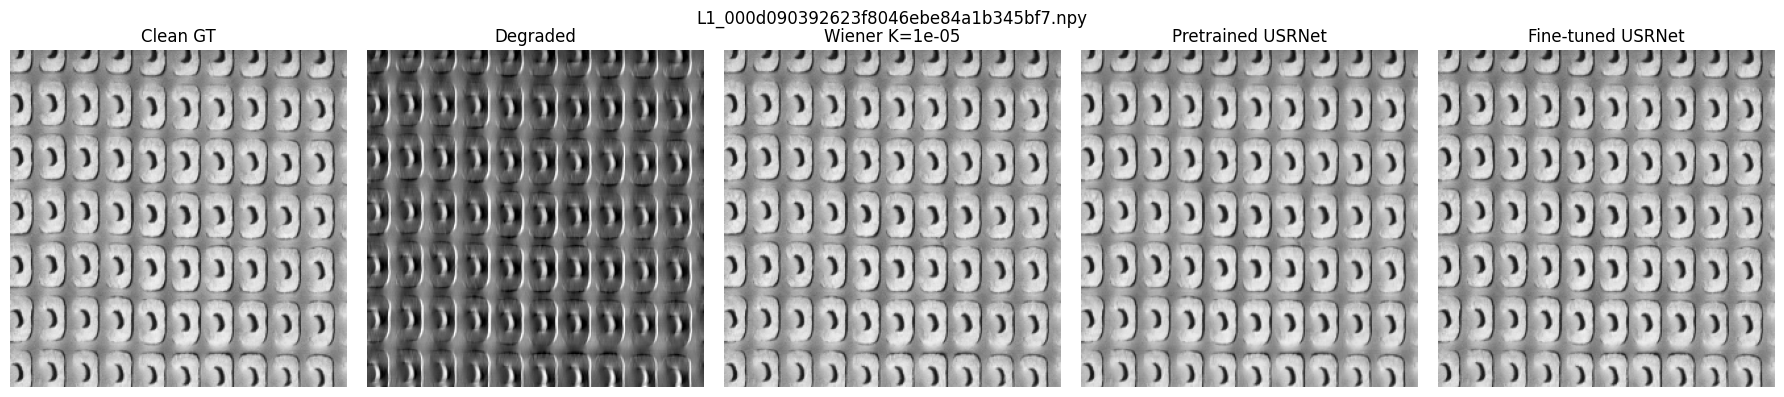

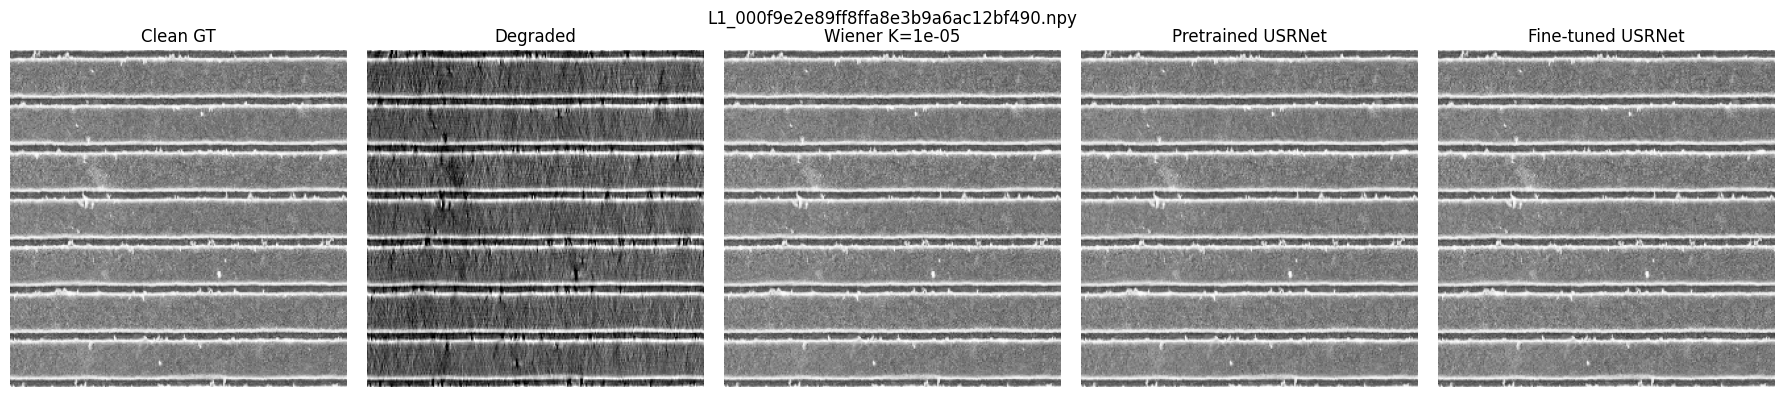

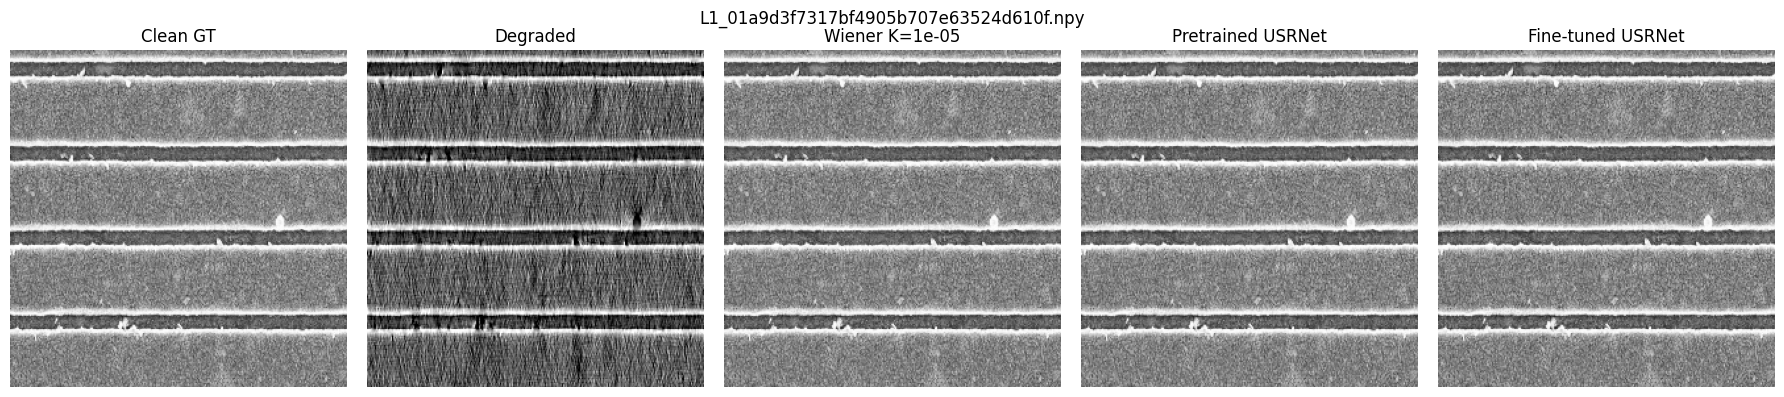

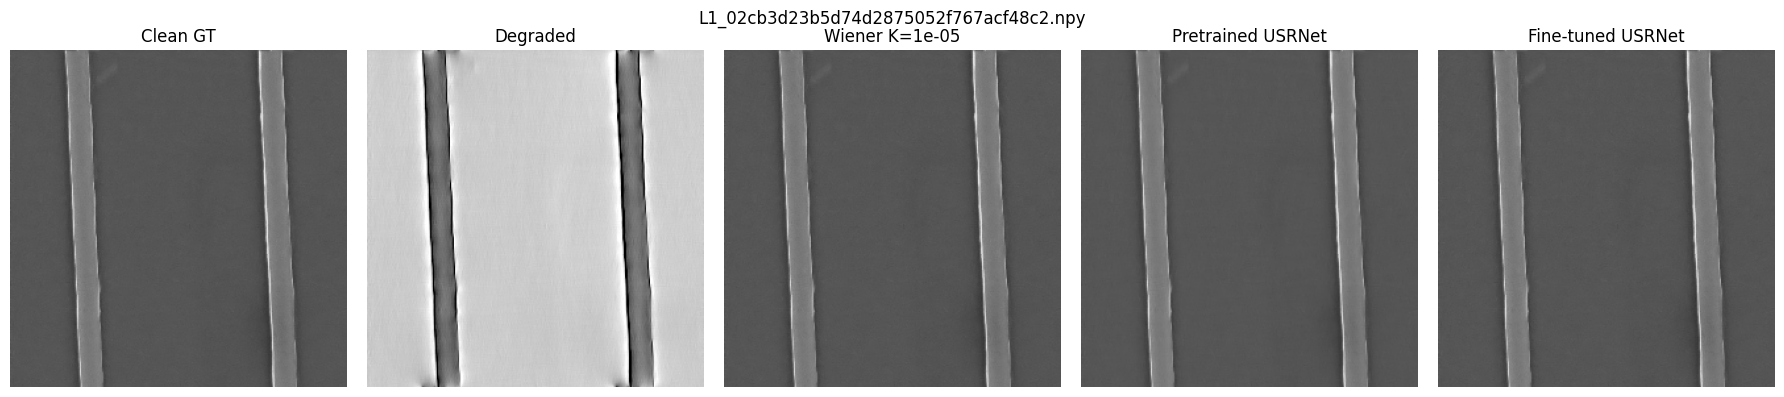

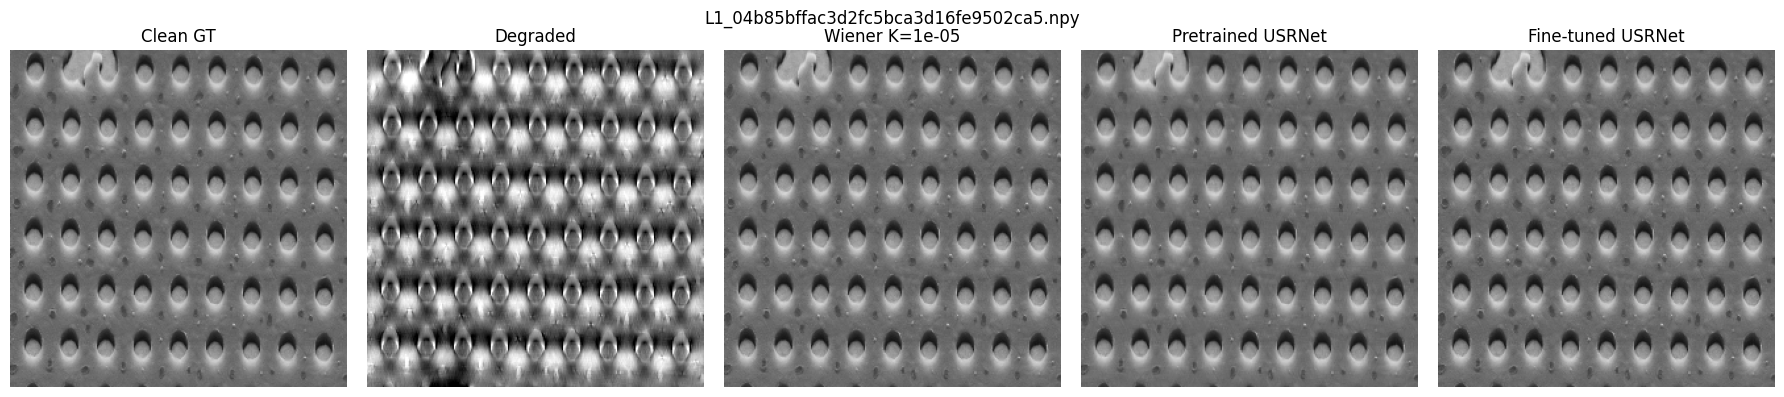

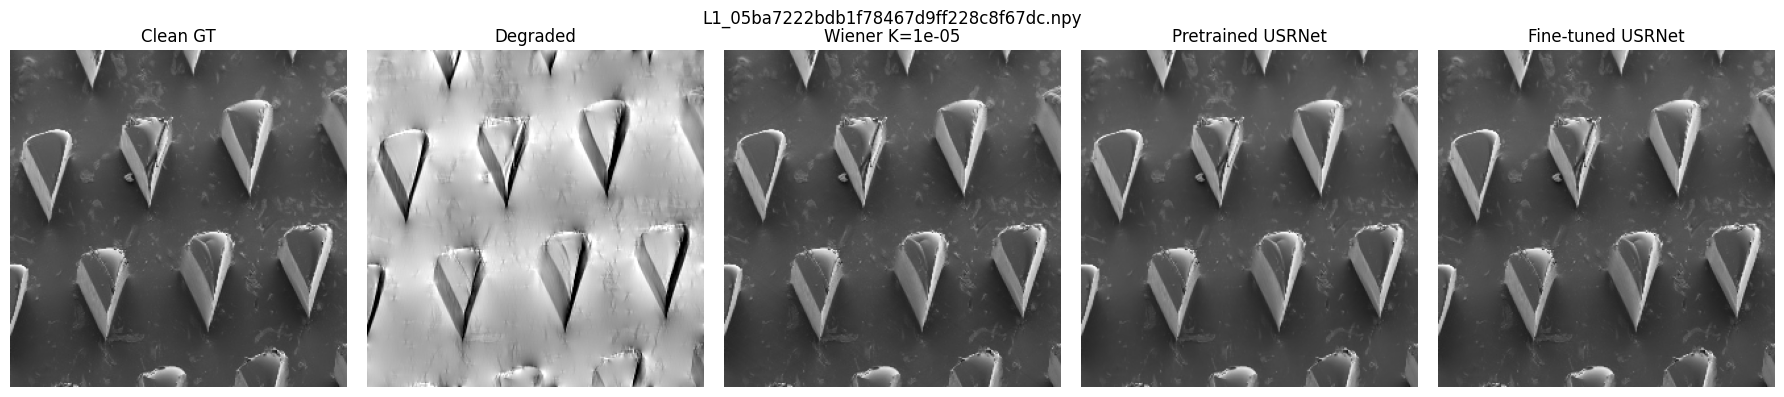

saved: /content/drive/MyDrive/Data scientist/팀프로젝트/5주차/logs_deconvolution_usrnet/test_figures


In [27]:
def predict_selected(state_dict, count):
    model.load_state_dict(state_dict, strict=True)
    model.eval()
    predictions = []
    with torch.inference_mode():
        for index in range(min(count, len(test_set))):
            item = test_set[index]
            degraded = item["degraded"].unsqueeze(0)
            kernel = item["kernel"].unsqueeze(0)
            sigma = item["sigma"].unsqueeze(0)
            output = usrnet_restore(model, degraded, kernel, sigma)[0, 0].float().clamp(0, 1).cpu().numpy()
            predictions.append(output)
    return predictions

pretrained_figures = predict_selected(pretrained_state_cpu, CFG.SAVE_FIGURES)
finetuned_figures = predict_selected(best_payload["model"], CFG.SAVE_FIGURES)
figure_dir = RUN_DIR / "test_figures"
figure_dir.mkdir(exist_ok=True)

for index in range(min(CFG.SAVE_FIGURES, len(test_set))):
    item = test_set[index]
    clean = item["clean"][0]
    degraded = item["degraded"][0]
    otf = dipole_otf(tuple(clean.shape), device="cpu")
    wiener = wiener_restore(degraded[None, None], otf, BEST_WIENER_K)[0, 0].clamp(0, 1).numpy()
    images = [clean.numpy(), degraded.numpy(), wiener, pretrained_figures[index], finetuned_figures[index]]
    titles = ["Clean GT", "Degraded", f"Wiener K={BEST_WIENER_K:g}", "Pretrained USRNet", "Fine-tuned USRNet"]
    fig, axes = plt.subplots(1, 5, figsize=(18, 4))
    for axis, image, title in zip(axes, images, titles):
        if title == "Degraded":
            axis.imshow(image, cmap="gray", vmin=np.percentile(image, 1), vmax=np.percentile(image, 99))
        else:
            axis.imshow(image, cmap="gray", vmin=0, vmax=1)
        axis.set_title(title)
        axis.axis("off")
    fig.suptitle(item["name"])
    fig.tight_layout()
    fig.savefig(figure_dir / f"{Path(item['name']).stem}.png", dpi=140, bbox_inches="tight")
    plt.show()
print("saved:", figure_dir)

## 7. Optional multi-orientation generalization check

The default experiment intentionally stops at `test_deconv_only`. Set `CFG.ENABLE_MULTI_TEST=True` only after the fixed-B0 model is complete. Each record's own `B0_dir` is converted to its own known PSF; this is still non-blind inference, not generic motion-blur inference.

In [28]:
class MultiOrientationDataset(Dataset):
    def __init__(self, label_dir, measure_root):
        self.label_dir = Path(label_dir)
        self.measure_root = Path(measure_root)
        metadata = self.measure_root / "forward_meta.json"
        self.records = json.loads(metadata.read_text(encoding="utf-8"))

    def __len__(self):
        return len(self.records)

    def __getitem__(self, index):
        record = self.records[index]
        relative = Path(record["file"])
        clean = KnownPSFDataset.load_npy(self.label_dir / relative.name)
        degraded = KnownPSFDataset.load_npy(self.measure_root / relative)
        b0_dir = tuple(float(value) for value in record["B0_dir"])
        otf = dipole_otf(tuple(clean.shape[-2:]), b0_dir=b0_dir)
        kernel = otf_to_usrnet_psf(otf).unsqueeze(0)
        sigma = torch.tensor([[[NOISE_STD]]], dtype=torch.float32)
        return {
            "clean": clean, "degraded": degraded, "kernel": kernel, "sigma": sigma,
            "name": relative.name, "orientation": record["B0_name"],
        }

if CFG.ENABLE_MULTI_TEST:
    multi_set = MultiOrientationDataset(DATA_ROOT / "test_label", DATA_ROOT / "test_deconv_multi")
    multi_loader = make_loader(multi_set, CFG.EVAL_BATCH, False)
    model.load_state_dict(best_payload["model"], strict=True)
    multi_metrics = evaluate_usrnet(model, multi_loader, "optional multi-orientation")
    multi_metrics.to_csv(RUN_DIR / "optional_multi_usrnet_psnr.csv", index=False)
else:
    print("Skipped: default experiment uses only test_deconv_only / B0_dir=(0.0, 1.0)")

Skipped: default experiment uses only test_deconv_only / B0_dir=(0.0, 1.0)


## Outputs

- `best_usrnet.pth`, `latest_usrnet.pth`
- `pretrained_val_metrics.csv`, `wiener_validation_sweep.csv`
- `test_psnr_per_image.csv`, `test_psnr_summary.csv`, `test_psnr_summary.json`
- `test_figures/*.png`

The core call is always `model(degraded_rgb, known_spatial_psf, sf=1, sigma_normalized)`.